# DAY 10
# DATE - 28.05.26
# Change Detection — Before and After Analysis

In [3]:
import numpy as np
import matplotlib.pyplot as plt

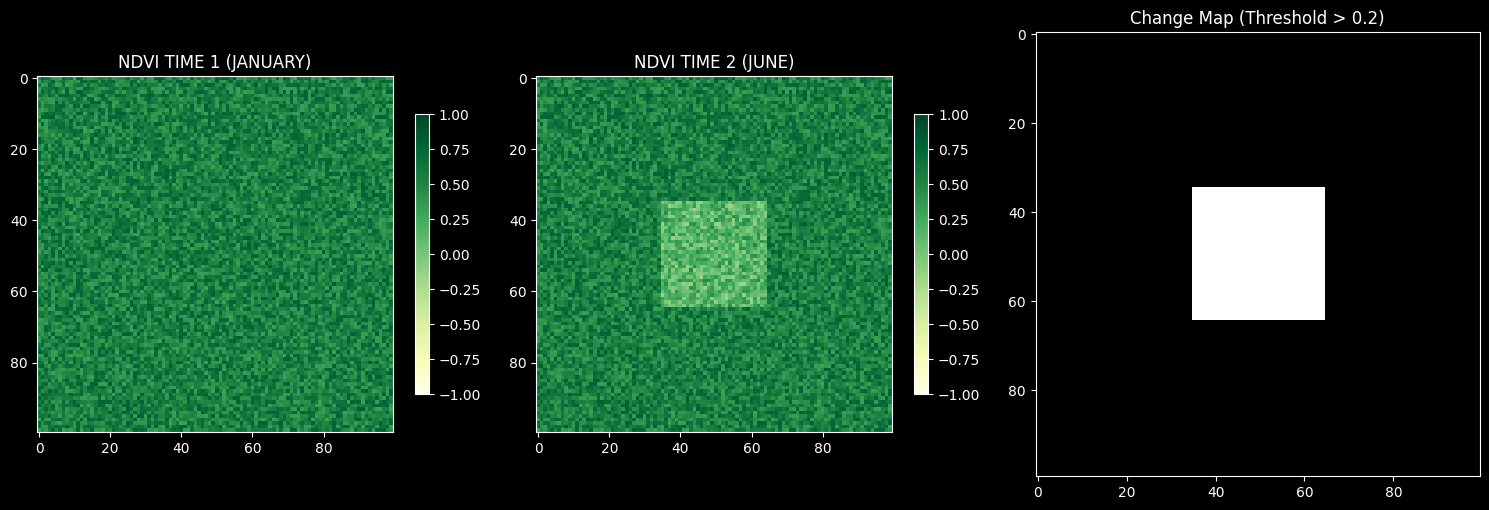

In [4]:
# 1. Create two dummy NDVI arrays (shape 100x100) representing Time 1 and Time 2
# NDVI values range between -1 and 1. We'll simulate some vegetation loss.

np.random.seed(42)
ndvi_t1 = np.random.uniform(0.3, 0.8, (100, 100))
ndvi_t2 = ndvi_t1.copy()

# Introduce a simulated change (e.g., deforestation patch in the center)

ndvi_t2[35:65, 35:65] -= np.random.uniform(0.3, 0.5, (30, 30))

# Ensure values stay within valid NDVI bounds [-1, 1]

ndvi_t2 = np.clip(ndvi_t2, -1, 1)

# 2. Subtract them to get a difference image (T1 - T2 to see drop in vegetation)
# Or T2 - T1 depending on preference; let's do absolute difference for simple magnitude

ndvi_diff = ndvi_t1 - ndvi_t2

# 3. Apply a threshold of 0.2 to identify changed pixels
# True where vegetation dropped by more than 0.2

change_map = ndvi_diff > 0.2

# 4. Visualize side by side using matplotlib

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# Plot NDVI Time 1

im1 = axes[0].imshow(ndvi_t1, cmap = 'YlGn', vmin = -1, vmax = 1)
axes[0].set_title('NDVI TIME 1 (JANUARY)')
fig.colorbar(im1, ax = axes[0], shrink = 0.6)

# Plot NDVI Time 2

im2 = axes[1].imshow(ndvi_t2, cmap = 'YlGn', vmin = -1, vmax = 1)
axes[1].set_title('NDVI TIME 2 (JUNE)')
fig.colorbar(im2, ax = axes[1], shrink = 0.6)

# Plot Change Map
im3 = axes[2].imshow(change_map, cmap = 'gray')
axes[2].set_title('Change Map (Threshold > 0.2)')

plt.tight_layout()
plt.show()